# Constructing Point Defects

## Overview

**Questions**
- Why are defects important?
- How can I simulate point defects?

**Objectives**
- Create supercells for defect calculations
- Introduce a point defect (substitutional impurity or vacancy)

**Key Points**
- Supercells are created with `make_supercell` using a supercell expansion matrix
- Point defects are introduced by modifying symbols (substitution), deleting atoms (vacancy) or inserting atoms (intersitital)
- Defect supercells typically need 100–200+ atoms

## Lecture Slides

The slides for this tutorial are embedded below.
[📥 Download slides (.pptx)](https://github.com/NU-CEM/Atomistic_Simulation/raw/2026/slides/Tutorial2_MaterialsBasics.pptx) &nbsp;|&nbsp; [Open in full screen](https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={afb0e74e-92c8-458b-9d1f-4111d88c8f10}&amp;action=embedview&amp;wdAr=1.7777777777777777)

<iframe
  src="https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={afb0e74e-92c8-458b-9d1f-4111d88c8f10}&amp;action=embedview&amp;wdAr=1.7777777777777777"
  width="100%"
  height="480"
  frameborder="0"
  allowfullscreen="true">
</iframe>

## Creating Supercells

Supercells are important for defect calculations, where a defect should not interact with its periodic images.

A rule of thumb is to use a supercell where the defect–defect image distance exceeds ~10 Å. 


### Example: Diamond supercell 

Start with the unit cell for diamond (a = 3.57 Å) 

In [13]:
from ase.build import bulk

diamond_primitive = bulk('C',   'diamond',  a=3.57)

print(f"Primitive cell: {len(diamond_primitive)} atoms")
print(f"Primitive cell dimensions: {diamond_primitive.cell.lengths()} Å")

Primitive cell: 2 atoms
Primitive cell dimensions: [2.52437121 2.52437121 2.52437121] Å


This shows we need at least a 4×4×4 supercell for the defect-defect image distance to be more than ~10 Å. First, we use `numpy` to create a supercell expansion matrix which specifies how we want our unit cell to be expanded.

In [14]:
import numpy as np

sc_matrix = np.diag([4, 4, 4])   

Use the `make_supercell` function in ase to create a supercell. We provide it with the supercell expansion matrix and the primitive unit cell:

In [15]:
from ase.build import make_supercell

diamond_super = make_supercell(diamond_primitive, sc_matrix)

print(f"4×4×4 supercell: {len(diamond_super)} atoms")
print(f"Supercell dimensions: {diamond_super.cell.lengths()} Å")

4×4×4 supercell: 128 atoms
Supercell dimensions: [10.09748484 10.09748484 10.09748484] Å


## Creating Point Defects

Point defects are central to quantum optics: the NV centre in diamond, the boron vacancy in hBN, and rare-earth substitutionals in wide-gap semiconductors are all point defects that emit single photons.

### Example: The NV centre in diamond

The **nitrogen-vacancy (NV) centre** consists of a substitutional nitrogen atom (N_C) adjacent to a carbon vacancy (V_C). It is the best-studied solid-state qubit and single-photon emitter.

1. Build a diamond supercell

In [21]:
sc_matrix = np.diag([4, 4, 4])  
nv_cell = make_supercell(diamond_primitive, sc_matrix)
print(f"Pristine supercell: {len(nv_cell)} atoms of C")

Pristine supercell: 128 atoms of C


2. Find two nearest neighbour C atoms using the `get_distances` function

In [22]:
from ase.geometry import get_distances
_, dist_matrix = get_distances(nv_cell.positions, nv_cell.positions,
                                cell=nv_cell.cell, pbc=True)
np.fill_diagonal(dist_matrix, np.inf)   # the diagonal is the distance between an atom and itself; fill this with infinity.
nearest_idx = np.argmin(dist_matrix[0])   # now use numpy's argmin function to find the nearest neighbour to atom 0
print(f"Nearest neighbour to atom 0: atom {nearest_idx}, "
      f"distance = {dist_matrix[0, nearest_idx]:.3f} Å")

Nearest neighbour to atom 0: atom 1, distance = 1.546 Å


3. Substitute atom 0 with nitrogen using the `setter` and `getter` methods from Lab 2

In [23]:
symbols = list(nv_cell.get_chemical_symbols())
symbols[0] = 'N'
nv_cell.set_chemical_symbols(symbols)
print(f"After N substitution: {nv_cell.get_chemical_formula()}")

After N substitution: C127N


4. Create a vacany at the nearest C site

In [25]:
del nv_cell[nearest_idx]
print(f"After vacancy creation: {nv_cell.get_chemical_formula()}")
print(f"NV supercell: {len(nv_cell)} atoms")

After vacancy creation: C126N
NV supercell: 127 atoms


5. Visualise the result

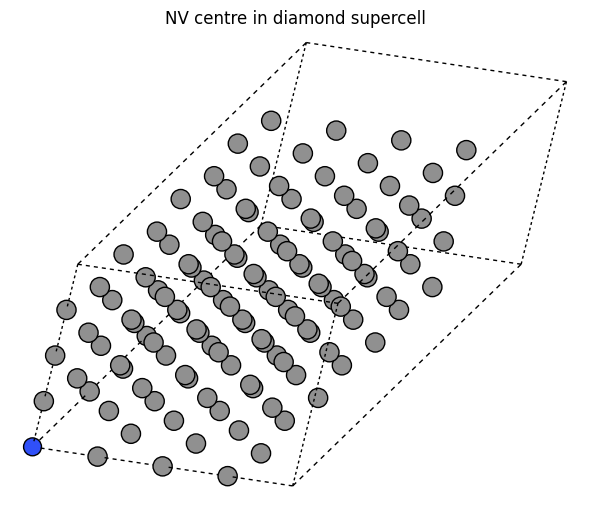

In [28]:
# Visualise the NV centre region
fig, ax = plt.subplots(figsize=(6, 6))
plot_atoms(nv_cell, ax, rotation=('10x,10y,0z'), radii=0.4)
ax.set_title('NV centre in diamond supercell')
ax.axis('off')
plt.tight_layout()
plt.show()

### Exercise: Boron vacancy in hBN

A) Build a 4×4×1 supercell of hexagonal boron nitride (hBN). hBN is a 2D material, so use `pbc=[True, True, False]` and add 20 Å of vacuum in the z-direction. Print the supercell dimensions and number of atoms.

B) The boron vacancy (V_B) in hBN is an emerging single-photon emitter. Starting from your hBN supercell, create a V_B defect by deleting one boron atom. 